**Note: I used the help of 2 LLMs for the implementation. The first one is Grok. The Grok results is better, so I put it first and the results in the submitted files are for Grok. I have also do more exploration and implement it with the help of Claude too.**

- Name: Farzan Rahmani
- Student number: 403210725

# This section was done with the help of the Grok LLM

## Install dependencies

In [ ]:
!sudo apt update && sudo apt install ffmpeg

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 https://cli.github.com/packages stable InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.6 kB]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,196 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,286 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-s

In [ ]:
!pip install librosa soundfile -q

In [ ]:
# restart the kernel

## Imports

In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import soundfile as sf
from scipy.signal import find_peaks
from scipy.fft import rfft, irfft

## Load Audio Files
We load the audio files at their original sample rate. For demonstration, we'll process 2.mp3 step by step with plots, then apply the full pipeline to all files.

In [ ]:
# List of files
files = ['2.mp3', '3.mp3', '4.mp3']

# Load audios
audios = {}
sample_rates = {}

for file in files:
    # Quick duration check without loading (requires FFmpeg for MP3)
    true_duration = librosa.get_duration(path=file)
    print(f"File {file} true duration (via metadata): {true_duration:.2f}s")

    y, sr = librosa.load(file, sr=None, mono=True)  # Force mono for simplicity
    audios[file] = y
    sample_rates[file] = sr
    print(f"Loaded {file}: Duration = {len(y)/sr:.2f}s, Sample Rate = {sr} Hz\n")

File 2.mp3 true duration (via metadata): 214.72s
Loaded 2.mp3: Duration = 214.23s, Sample Rate = 44100 Hz

File 3.mp3 true duration (via metadata): 188.59s
Loaded 3.mp3: Duration = 188.16s, Sample Rate = 44100 Hz

File 4.mp3 true duration (via metadata): 154.61s
Loaded 4.mp3: Duration = 154.25s, Sample Rate = 44100 Hz



## Step 1: Visualize Original Audio (Example: 2.mp3)
Plot the waveform and spectrogram of the original audio to see the issues (e.g., silence, noise, bass dominance).

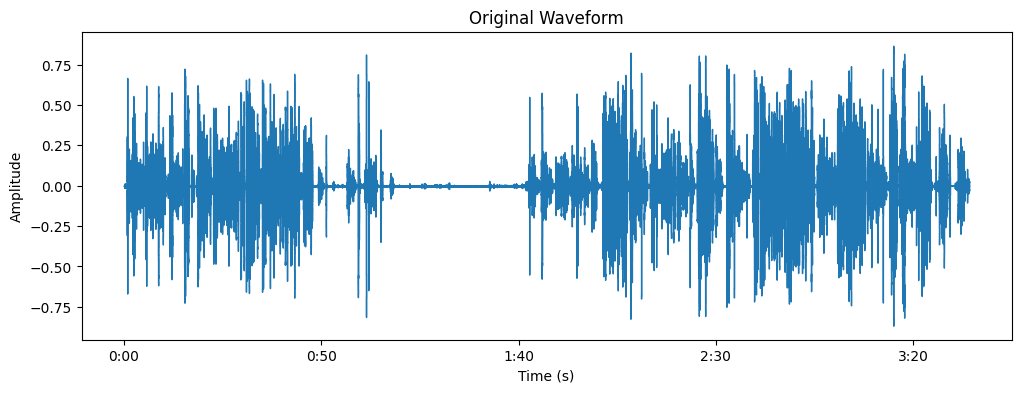

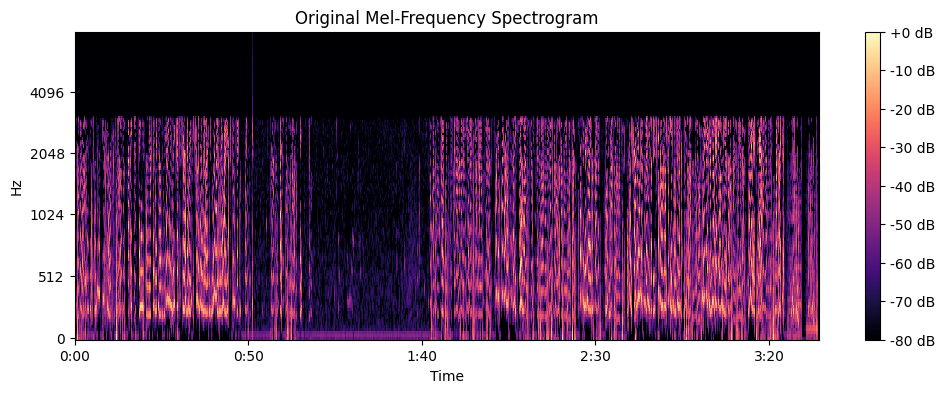

In [ ]:
# Select example file
example_file = '2.mp3'
y = audios[example_file]
sr = sample_rates[example_file]

# Plot waveform
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title('Original Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

# Plot spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)
plt.figure(figsize=(12, 4))
librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000)
plt.colorbar(format='%+2.0f dB')
plt.title('Original Mel-Frequency Spectrogram')
plt.show()

## Step 2: Remove Silence
Trim leading/trailing silence and remove internal long silence segments (e.g., >0.5s below a threshold). This uses RMS energy to detect silent parts.

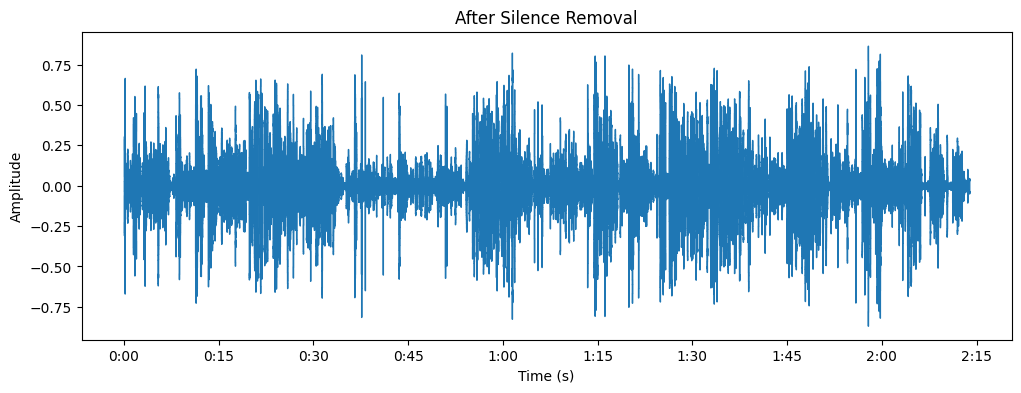

In [ ]:
# Trim leading/trailing silence
y_trim, _ = librosa.effects.trim(y, top_db=25)  # 25 dB threshold for silence

# Detect and remove internal silences (keep only non-silent segments longer than 0.5s)
hop_length = 512  # Default hop_length used in RMS computation
rms = librosa.feature.rms(y=y_trim, hop_length=hop_length)[0]
rms_threshold = np.max(rms) * 0.01  # 1% of max RMS as silence threshold
min_non_silent_frames = int(0.5 * sr / hop_length)  # 0.5s in frames

# Find non-silent segments
segments = []
start = None
for i, r in enumerate(rms):
    if r > rms_threshold:
        if start is None:
            start = i
    else:
        if start is not None:
            if i - start >= min_non_silent_frames:  # Only keep if non-silent segment is at least 0.5s long
                segments.append((start, i))
            start = None
if start is not None and len(rms) - start >= min_non_silent_frames:
    segments.append((start, len(rms)))

# Concatenate non-silent segments
y_no_silence = np.concatenate([y_trim[s*hop_length : e*hop_length] for s, e in segments])

# Plot result
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y_no_silence, sr=sr)
plt.title('After Silence Removal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

## Step 3: Normalize Volume
Normalize the audio to handle volume increases/decreases. This scales the signal to [-1, 1].

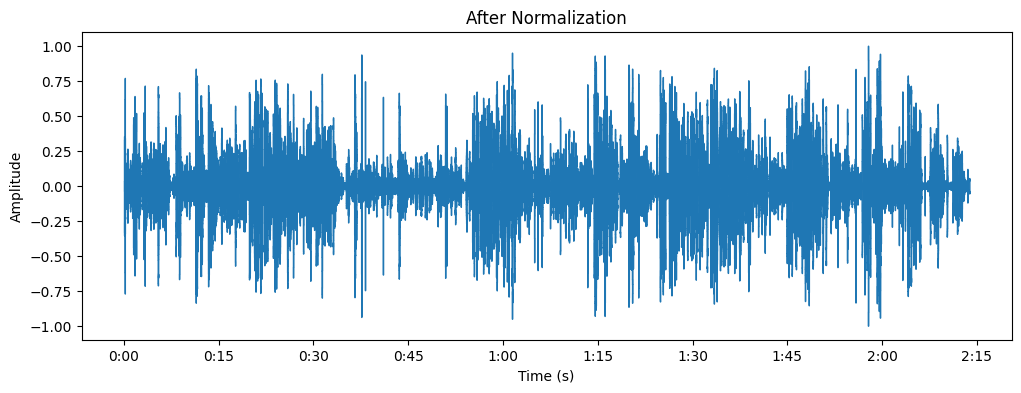

In [ ]:
y_norm = librosa.util.normalize(y_no_silence)

# Plot result
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y_norm, sr=sr)
plt.title('After Normalization')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

## Step 4: Denoise (Noise Reduction)
Use Wiener filter for general noise reduction (handles various noises). Assumes noise is additive.

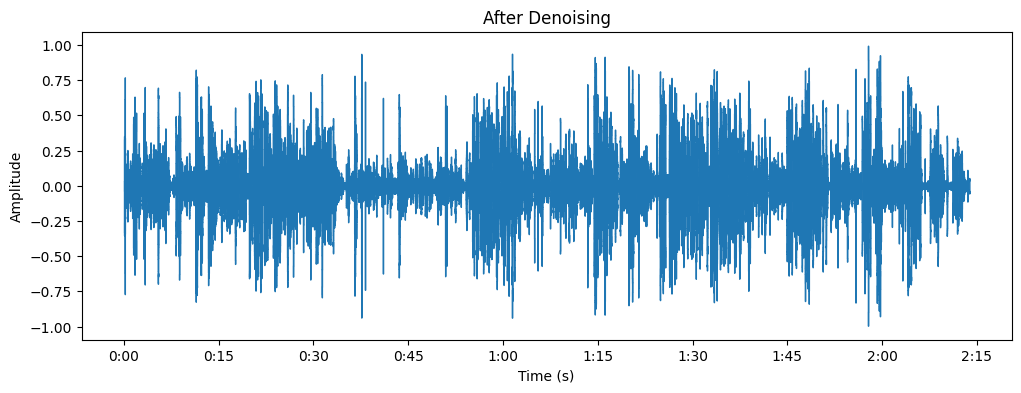

In [ ]:
# Apply Wiener filter (estimates noise automatically)
y_denoise = signal.wiener(y_norm, mysize=5)  # Small window for estimation

# Plot result
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y_denoise, sr=sr)
plt.title('After Denoising')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

## Step 5: Echo Removal (Approximate Using Cepstrum)
Estimate echo delay via cepstrum and subtract the echoed signal. This is a basic blind echo cancellation; works best for simple echoes.

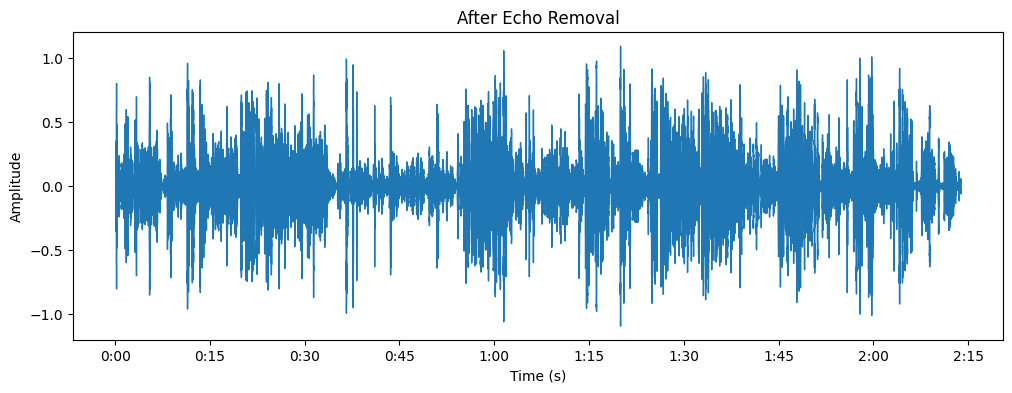

In [ ]:
# Function for echo removal using cepstrum
def remove_echo(y, sr, min_delay=0.05, max_delay=0.5):
    # Compute cepstrum
    cepstrum = irfft(np.log(np.abs(rfft(y)) + 1e-10))  # Avoid log(0)

    # Find peaks in cepstrum for echo delay (quefrency)
    quefrency_min = int(min_delay * sr)
    quefrency_max = int(max_delay * sr)
    peaks, _ = find_peaks(cepstrum[quefrency_min:quefrency_max], height=np.mean(cepstrum))

    if len(peaks) > 0:
        delay = peaks[0] + quefrency_min  # First peak as echo delay
        gain = 0.5  # Assume echo gain (adjustable)
        y_echo_removed = y.copy()
        if delay < len(y):
            y_echo_removed[delay:] -= gain * y[:-delay]
        return y_echo_removed
    else:
        return y  # No echo detected

y_echo_removed = remove_echo(y_denoise, sr)

# Plot result
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y_echo_removed, sr=sr)
plt.title('After Echo Removal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

## Step 6: Remove Waiting Tone (Notch Filter)
Assume waiting tones are around 440 Hz (common beep) or similar. Use a notch filter to attenuate specific frequencies.

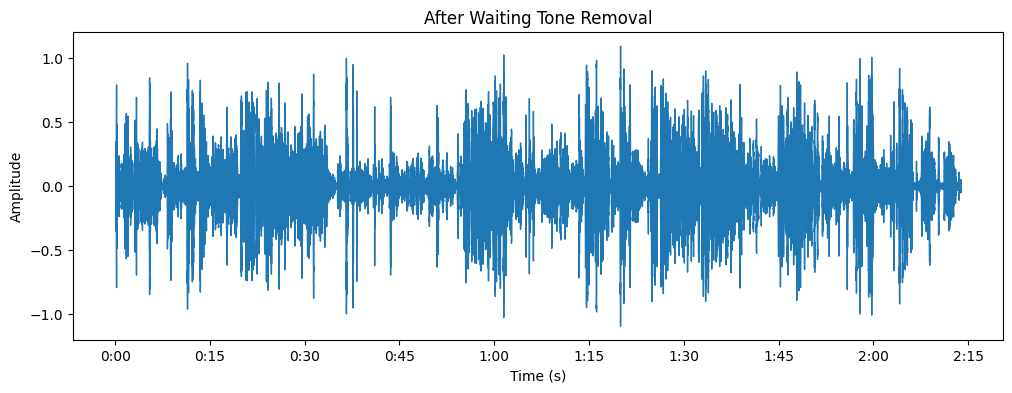

In [ ]:
# Design notch filter for common waiting tone frequencies (e.g., 440 Hz, adjustable)
def notch_filter(y, sr, freq=440, Q=30):
    w0 = freq / (sr / 2)
    b, a = signal.iirnotch(w0, Q)
    return signal.lfilter(b, a, y)

y_no_tone = notch_filter(y_echo_removed, sr, freq=440)  # Add more calls for other freqs if known

# Plot result
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y_no_tone, sr=sr)
plt.title('After Waiting Tone Removal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

## Step 7: Equalize for Low Bandwidth (Boost Highs)
Telephone audio is bass-heavy (low bandwidth). Apply a high-shelf filter to boost frequencies above 1kHz gently.

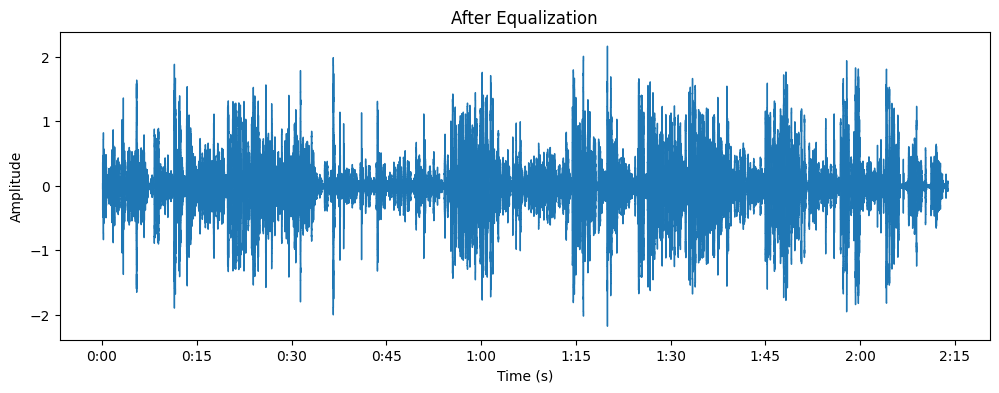

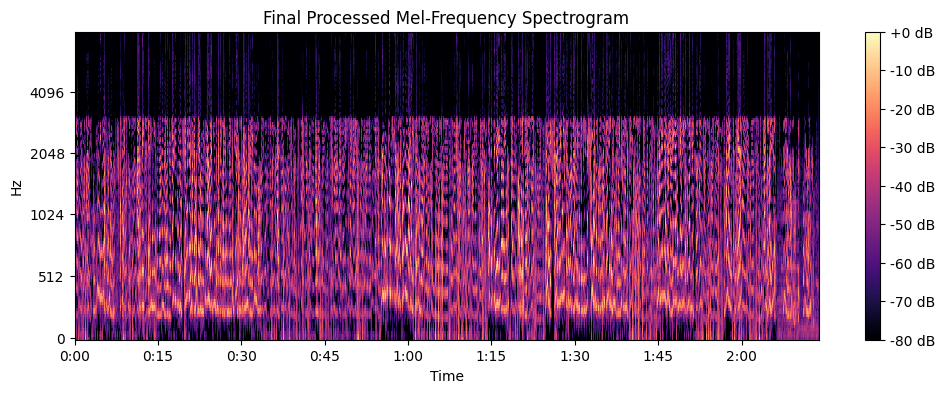

In [ ]:
# Design high-shelf filter (boost highs)
def high_shelf_filter(y, sr, freq=1000, gain_db=6, Q=0.707):
    w0 = freq / (sr / 2)
    A = 10**(gain_db / 40)
    alpha = np.sin(w0) / (2 * Q)

    b0 = A * ((A + 1) + (A - 1) * np.cos(w0) + 2 * np.sqrt(A) * alpha)
    b1 = -2 * A * ((A - 1) + (A + 1) * np.cos(w0))
    b2 = A * ((A + 1) + (A - 1) * np.cos(w0) - 2 * np.sqrt(A) * alpha)
    a0 = (A + 1) - (A - 1) * np.cos(w0) + 2 * np.sqrt(A) * alpha
    a1 = 2 * ((A - 1) - (A + 1) * np.cos(w0))
    a2 = (A + 1) - (A - 1) * np.cos(w0) - 2 * np.sqrt(A) * alpha

    b = np.array([b0, b1, b2]) / a0
    a = np.array([1, a1/a0, a2/a0])

    return signal.lfilter(b, a, y)

y_eq = high_shelf_filter(y_no_tone, sr)

# Plot result
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y_eq, sr=sr)
plt.title('After Equalization')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

# Plot final spectrogram
S = librosa.feature.melspectrogram(y=y_eq, sr=sr, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)
plt.figure(figsize=(12, 4))
librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000)
plt.colorbar(format='%+2.0f dB')
plt.title('Final Processed Mel-Frequency Spectrogram')
plt.show()

## Final Step: Apply Pipeline to All Files and Save Processed Audio
Now apply the full pipeline (steps 2-7) to all files and save as WAV.

In [ ]:
# Full processing function
def process_audio(y, sr):
    # Step 2: Remove silence
    y_trim, _ = librosa.effects.trim(y, top_db=25)
    rms = librosa.feature.rms(y=y_trim)[0]
    rms_threshold = np.max(rms) * 0.01
    frame_length = len(y_trim) // len(rms)
    min_silence_frames = int(0.5 * sr / frame_length)
    segments = []
    start = None
    for i, r in enumerate(rms):
        if r > rms_threshold:
            if start is None:
                start = i
        else:
            if start is not None:
                if i - start >= min_silence_frames:
                    segments.append((start, i))
                start = None
    if start is not None and len(rms) - start >= min_silence_frames:
        segments.append((start, len(rms)))
    y_no_silence = np.concatenate([y_trim[s*frame_length : e*frame_length] for s, e in segments])

    # Step 3: Normalize
    y_norm = librosa.util.normalize(y_no_silence)

    # Step 4: Denoise
    y_denoise = signal.wiener(y_norm, mysize=5)

    # Step 5: Echo removal
    y_echo_removed = remove_echo(y_denoise, sr)

    # Step 6: Remove waiting tone
    y_no_tone = notch_filter(y_echo_removed, sr, freq=440)

    # Step 7: Equalize
    y_eq = high_shelf_filter(y_no_tone, sr)

    return y_eq

# Process and save all
for file in files:
    y = audios[file]
    sr = sample_rates[file]
    y_processed = process_audio(y, sr)
    output_file = file.replace('.mp3', '_processed.wav')
    sf.write(output_file, y_processed, sr)
    print(f"Saved processed audio to {output_file}")

Saved processed audio to 2_processed.wav
Saved processed audio to 3_processed.wav
Saved processed audio to 4_processed.wav


In [ ]:
--------------

# This section was done with the help of the Claude LLM

Call Center Audio Processing with DSP
This notebook processes audio files to remove noise, echo, silence, and other artifacts


## Install and Import Required Libraries

In [ ]:
!pip install librosa soundfile noisereduce scipy numpy matplotlib pydub -q

In [ ]:
import librosa
import librosa.display
import soundfile as sf
import noisereduce as nr
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import wiener, butter, sosfilt, stft, istft
from pydub import AudioSegment
from pydub.silence import detect_nonsilent
import warnings
warnings.filterwarnings('ignore')

## Load Audio Files
Load all three audio files and display basic information


In [ ]:
audio_files = ['2.mp3', '3.mp3', '4.mp3']
audio_data = {}

for file in audio_files:
    try:
        # Load audio file
        y, sr = librosa.load(file, sr=None)  # Keep original sample rate
        audio_data[file] = {'original': y, 'sr': sr, 'current': y}

        print(f"\n{file}:")
        print(f"  Sample Rate: {sr} Hz")
        print(f"  Duration: {len(y)/sr:.2f} seconds")
        print(f"  Samples: {len(y)}")
        print(f"  Max amplitude: {np.max(np.abs(y)):.4f}")
    except Exception as e:
        print(f"Error loading {file}: {e}")


2.mp3:
  Sample Rate: 44100 Hz
  Duration: 214.23 seconds
  Samples: 9447552
  Max amplitude: 0.8673

3.mp3:
  Sample Rate: 44100 Hz
  Duration: 188.16 seconds
  Samples: 8297856
  Max amplitude: 2.0312

4.mp3:
  Sample Rate: 44100 Hz
  Duration: 154.25 seconds
  Samples: 6802560
  Max amplitude: 1.4592


## Visualize Original Audio
Visualize waveform and spectrogram of original audio

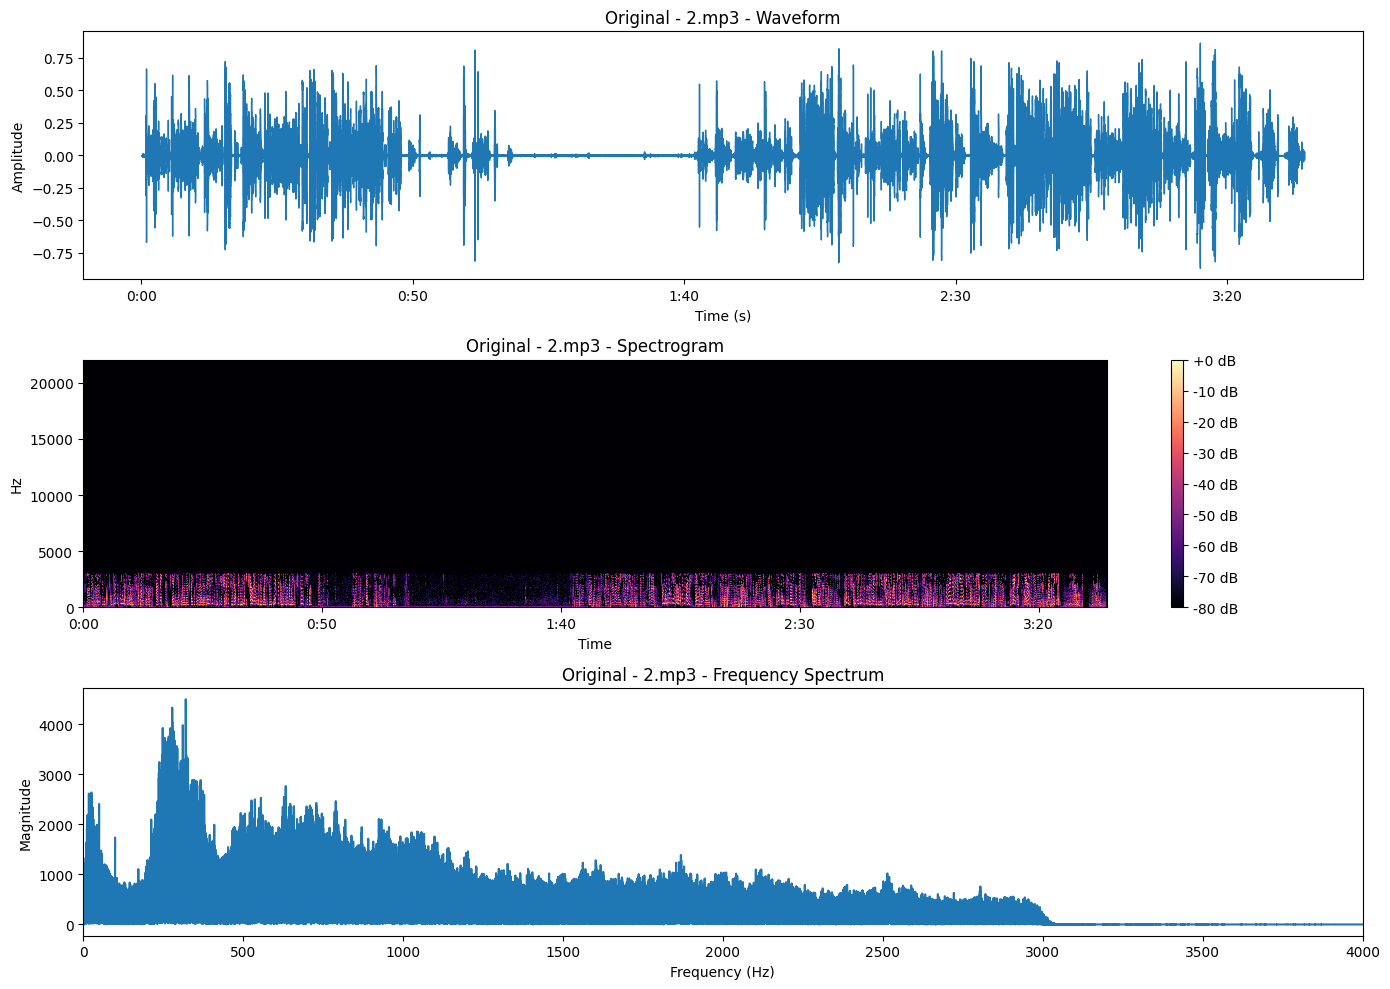

In [ ]:
def plot_audio_analysis(y, sr, title):
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # Waveform
    librosa.display.waveshow(y, sr=sr, ax=axes[0])
    axes[0].set_title(f'{title} - Waveform')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')

    # Spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[1])
    axes[1].set_title(f'{title} - Spectrogram')
    fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

    # Spectrum (average)
    freqs = np.fft.rfftfreq(len(y), 1/sr)
    spectrum = np.abs(np.fft.rfft(y))
    axes[2].plot(freqs, spectrum)
    axes[2].set_title(f'{title} - Frequency Spectrum')
    axes[2].set_xlabel('Frequency (Hz)')
    axes[2].set_ylabel('Magnitude')
    axes[2].set_xlim(0, 4000)  # Focus on telephone bandwidth

    plt.tight_layout()
    plt.show()

# Visualize first file
file = audio_files[0]
plot_audio_analysis(audio_data[file]['original'], audio_data[file]['sr'],
                   f"Original - {file}")

## Step 1 - Noise Reduction
Apply noise reduction using spectral gating

Applying noise reduction...
  2.mp3: Noise reduction complete
  3.mp3: Noise reduction complete
  4.mp3: Noise reduction complete


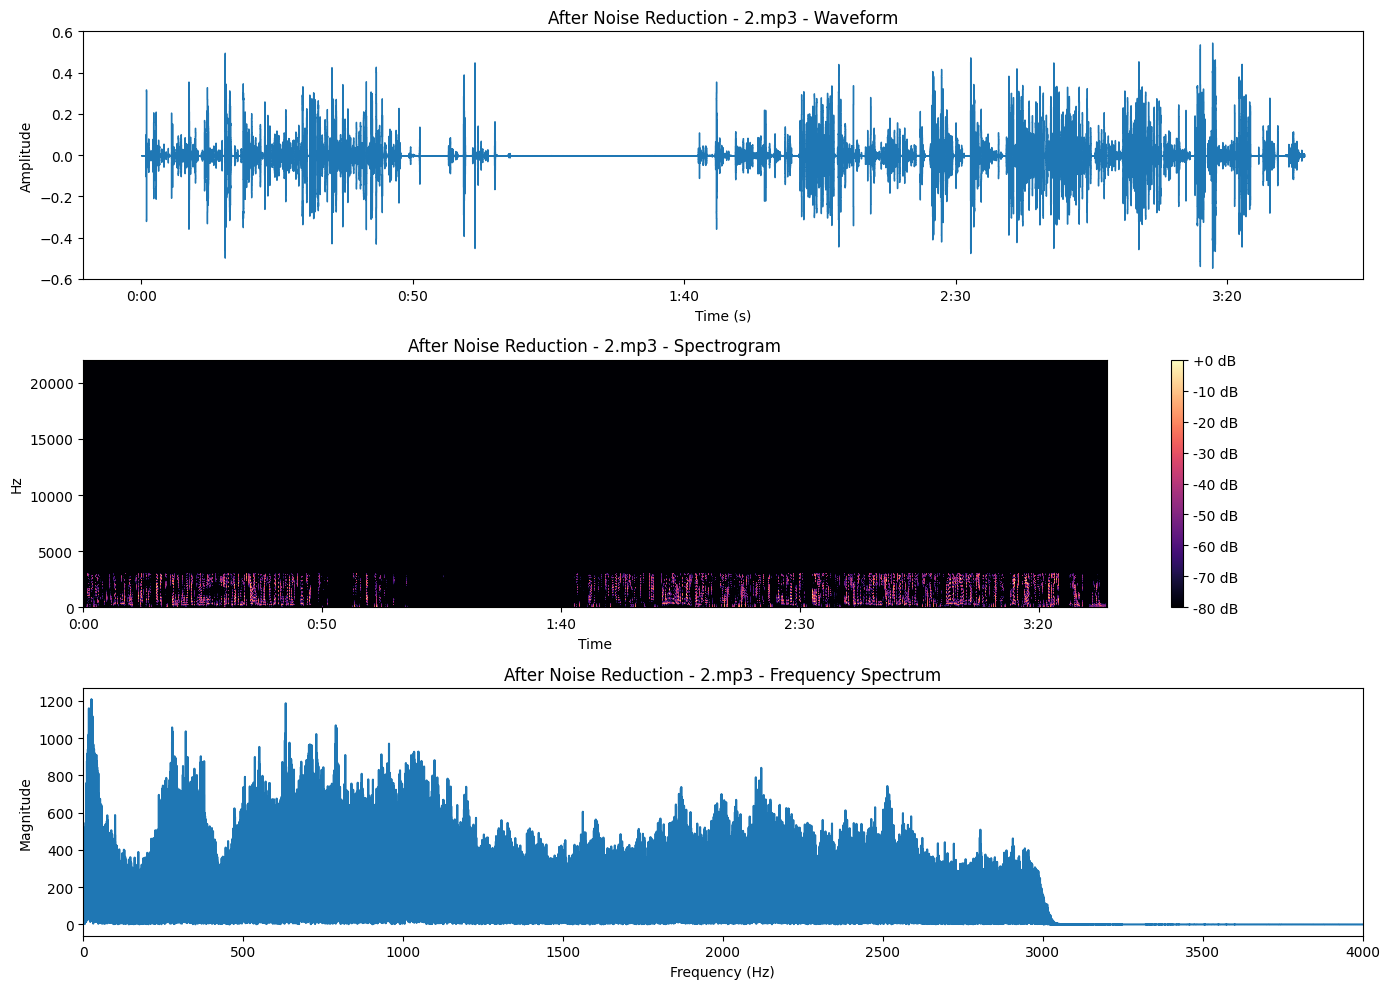

In [ ]:
def reduce_noise(y, sr, prop_decrease=1.0):
    # Use first 0.5 seconds as noise profile (adjust if needed)
    noise_sample = y[0:int(sr*0.5)]

    # Apply noise reduction
    y_denoised = nr.reduce_noise(y=y, sr=sr,
                                  stationary=True,
                                  prop_decrease=prop_decrease)
    return y_denoised

print("Applying noise reduction...")
for file in audio_files:
    y_denoised = reduce_noise(audio_data[file]['current'], audio_data[file]['sr'])
    audio_data[file]['denoised'] = y_denoised
    audio_data[file]['current'] = y_denoised
    print(f"  {file}: Noise reduction complete")

# Visualize result for first file
file = audio_files[0]
plot_audio_analysis(audio_data[file]['denoised'], audio_data[file]['sr'],
                   f"After Noise Reduction - {file}")

## Step 2 - Echo Removal
Remove echo using FFT-based correlation

Applying echo removal (optimized)...
  Processing 2.mp3...
    No significant echo detected
  Processing 3.mp3...
    No significant echo detected
  Processing 4.mp3...
    Detected echo: delay=61.0ms, strength=0.443


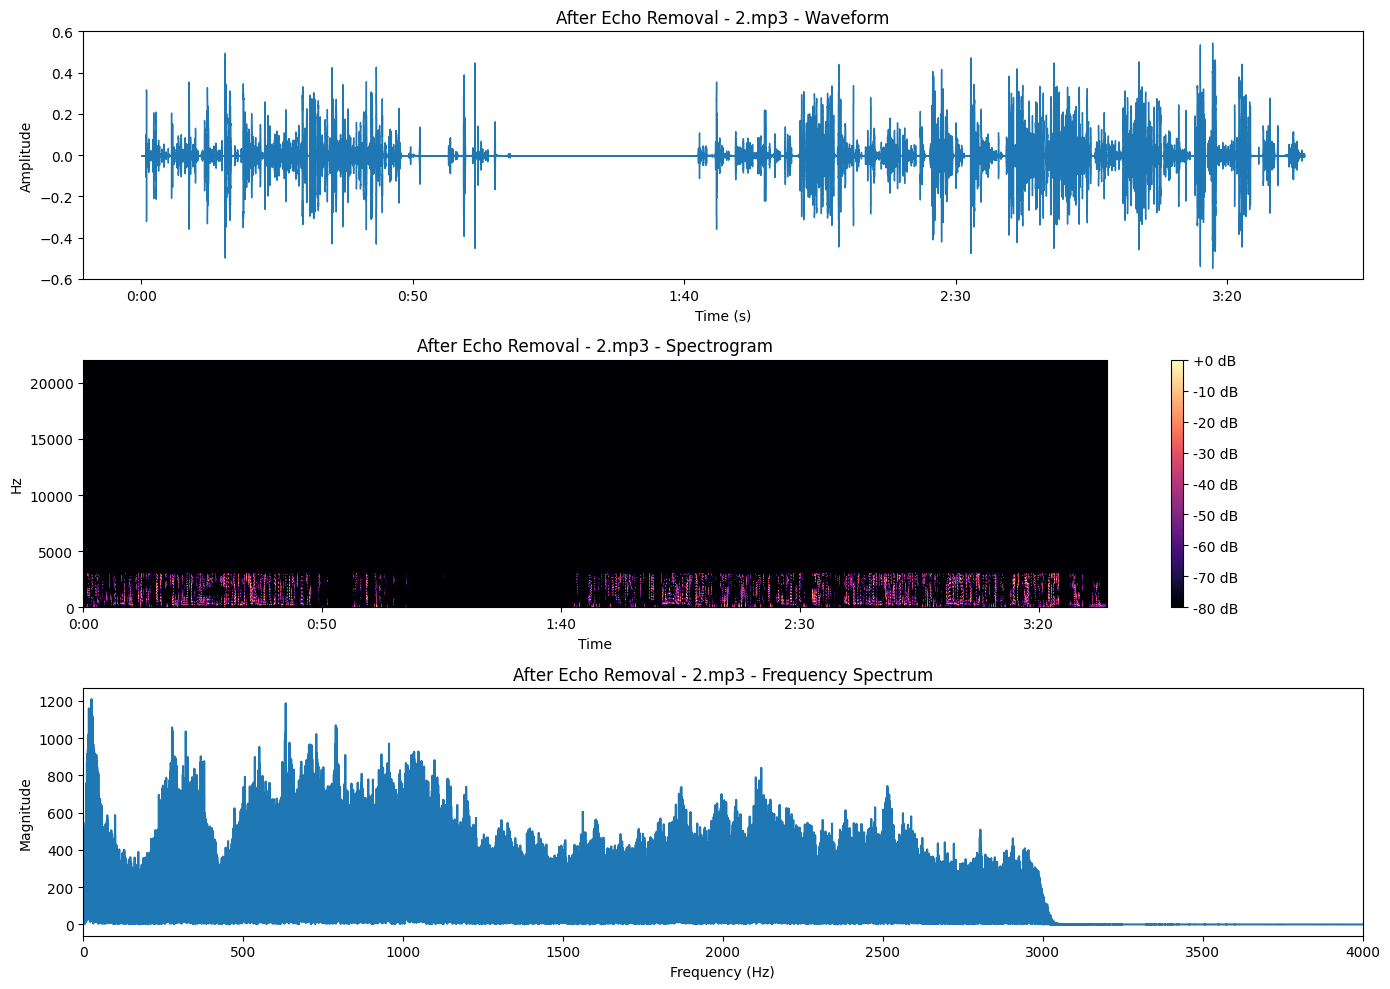

In [ ]:
def remove_echo_fast(y, sr):
    # Work on a smaller sample to detect echo (first 5 seconds or whole audio if shorter)
    sample_length = min(len(y), int(5 * sr))
    y_sample = y[:sample_length]

    # Use FFT-based autocorrelation (much faster: O(n log n) vs O(n²))
    fft_y = np.fft.rfft(y_sample, n=2*len(y_sample))
    autocorr = np.fft.irfft(fft_y * np.conj(fft_y))
    autocorr = autocorr[:len(y_sample)]
    autocorr = autocorr / autocorr[0]  # Normalize

    # Look for echo in typical telephone range: 50-300ms
    min_delay = int(0.05 * sr)  # 50ms
    max_delay = int(0.3 * sr)   # 300ms

    if max_delay >= len(autocorr):
        return y  # Sample too short

    # Find peaks in the echo range
    search_region = autocorr[min_delay:max_delay]
    peaks, properties = signal.find_peaks(search_region,
                                          height=0.15,  # Lower threshold
                                          distance=int(0.02*sr))

    if len(peaks) > 0:
        # Get the most prominent peak
        peak_idx = peaks[np.argmax(properties['peak_heights'])]
        echo_delay = peak_idx + min_delay
        echo_strength = autocorr[echo_delay]

        print(f"    Detected echo: delay={echo_delay/sr*1000:.1f}ms, strength={echo_strength:.3f}")

        if echo_strength > 0.1:
            # Apply echo cancellation to entire signal
            y_delayed = np.pad(y, (echo_delay, 0), mode='constant')[:-echo_delay]
            # Reduce echo strength by factor (0.6 works well empirically)
            y_decho = y - echo_strength * 0.6 * y_delayed
            return y_decho
    else:
        print(f"    No significant echo detected")

    return y

print("Applying echo removal (optimized)...")
for file in audio_files:
    print(f"  Processing {file}...")
    y_decho = remove_echo_fast(audio_data[file]['current'], audio_data[file]['sr'])
    audio_data[file]['decho'] = y_decho
    audio_data[file]['current'] = y_decho

# Visualize result
file = audio_files[0]
plot_audio_analysis(audio_data[file]['decho'], audio_data[file]['sr'],
                   f"After Echo Removal - {file}")

##  Step 3 - Silence Removal
Detect and remove silence segments



Removing silence...
  2.mp3: 214.23s -> 164.37s (removed 49.86s)
  3.mp3: 188.16s -> 120.68s (removed 67.48s)
  4.mp3: 154.25s -> 148.68s (removed 5.57s)


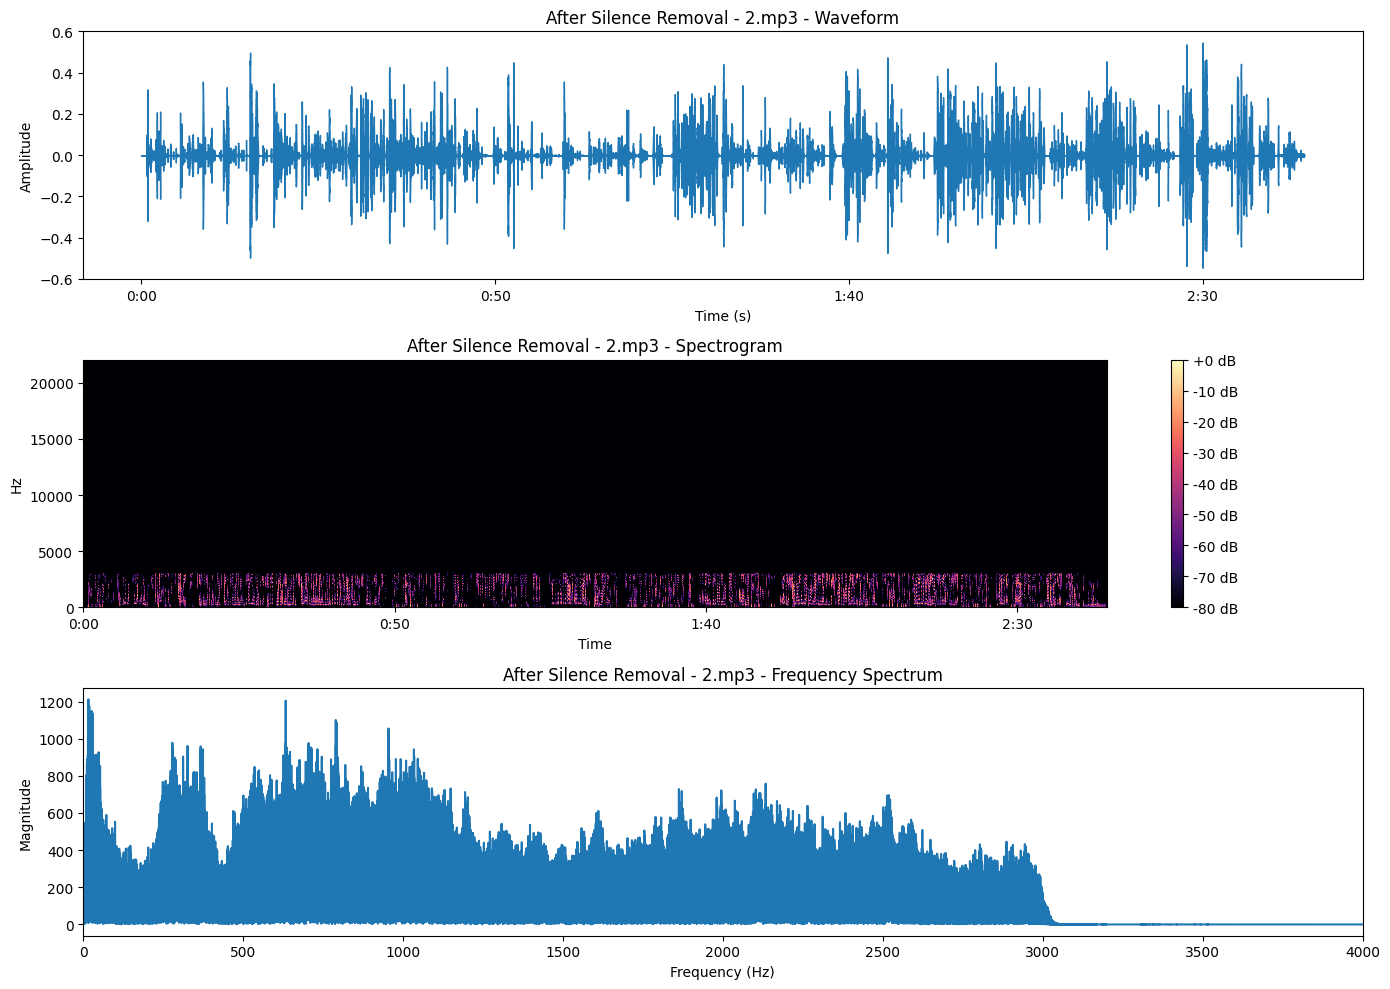

In [ ]:
def remove_silence(y, sr, silence_thresh=-120, min_silence_len=1000, padding=100):
    # Convert to AudioSegment for silence detection
    y_int = (y * 32767).astype(np.int16)
    audio_segment = AudioSegment(
        y_int.tobytes(),
        frame_rate=sr,
        sample_width=2,
        channels=1
    )

    # Detect non-silent chunks
    nonsilent_ranges = detect_nonsilent(
        audio_segment,
        min_silence_len=min_silence_len,
        silence_thresh=silence_thresh,
        seek_step=10
    )

    # Reconstruct audio without silence
    if nonsilent_ranges:
        y_segments = []
        for start_ms, end_ms in nonsilent_ranges:
            start_sample = int(start_ms * sr / 1000)
            end_sample = int(end_ms * sr / 1000)

            # Add padding
            start_sample = max(0, start_sample - padding)
            end_sample = min(len(y), end_sample + padding)

            y_segments.append(y[start_sample:end_sample])

        y_no_silence = np.concatenate(y_segments)
        return y_no_silence

    return y

print("Removing silence...")
for file in audio_files:
    y_no_silence = remove_silence(audio_data[file]['current'], audio_data[file]['sr'])
    audio_data[file]['no_silence'] = y_no_silence
    audio_data[file]['current'] = y_no_silence

    original_duration = len(audio_data[file]['original']) / audio_data[file]['sr']
    new_duration = len(y_no_silence) / audio_data[file]['sr']
    print(f"  {file}: {original_duration:.2f}s -> {new_duration:.2f}s " +
          f"(removed {original_duration-new_duration:.2f}s)")

# Visualize result
file = audio_files[0]
plot_audio_analysis(audio_data[file]['no_silence'], audio_data[file]['sr'],
                   f"After Silence Removal - {file}")

## Step 4 - Normalize Volume (Dynamic Range Compression)
Normalize audio levels and apply compression


Normalizing volume and applying compression...
  2.mp3: Volume normalization complete
  3.mp3: Volume normalization complete
  4.mp3: Volume normalization complete


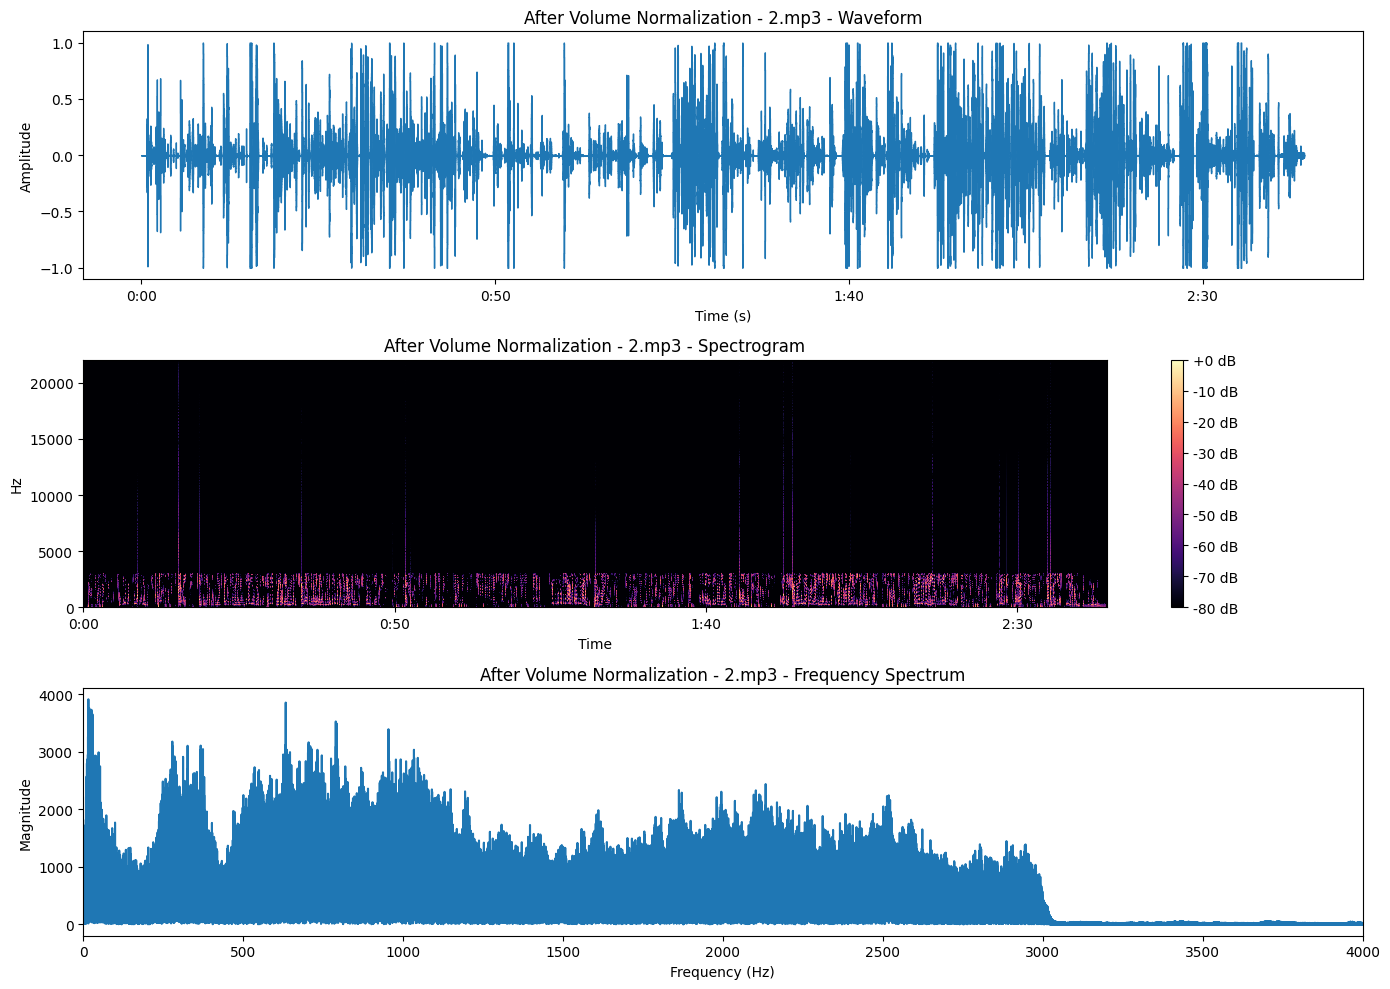

In [ ]:
def normalize_audio(y, target_level=-20.0):
    # Calculate current RMS
    rms = np.sqrt(np.mean(y**2))
    current_db = 20 * np.log10(rms) if rms > 0 else -100

    # Calculate gain needed
    gain_db = target_level - current_db
    gain_linear = 10 ** (gain_db / 20)

    # Apply gain
    y_normalized = y * gain_linear

    # Clip to prevent distortion
    y_normalized = np.clip(y_normalized, -1.0, 1.0)

    return y_normalized

def compress_audio(y, threshold=0.3, ratio=4.0):
    """Apply dynamic range compression"""
    y_compressed = y.copy()

    # Find samples above threshold
    mask = np.abs(y) > threshold

    # Apply compression
    sign = np.sign(y_compressed[mask])
    magnitude = np.abs(y_compressed[mask])
    compressed_magnitude = threshold + (magnitude - threshold) / ratio
    y_compressed[mask] = sign * compressed_magnitude

    return y_compressed

print("Normalizing volume and applying compression...")
for file in audio_files:
    y_compressed = compress_audio(audio_data[file]['current'])
    y_normalized = normalize_audio(y_compressed)
    audio_data[file]['normalized'] = y_normalized
    audio_data[file]['current'] = y_normalized
    print(f"  {file}: Volume normalization complete")

# Visualize result
file = audio_files[0]
plot_audio_analysis(audio_data[file]['normalized'], audio_data[file]['sr'],
                   f"After Volume Normalization - {file}")

## Step 5 - Bandwidth Enhancement (Telephone Audio)
Apply filters to enhance telephone bandwidth and reduce bass



Enhancing telephone audio bandwidth...
  2.mp3: Bandwidth enhancement complete
  3.mp3: Bandwidth enhancement complete
  4.mp3: Bandwidth enhancement complete


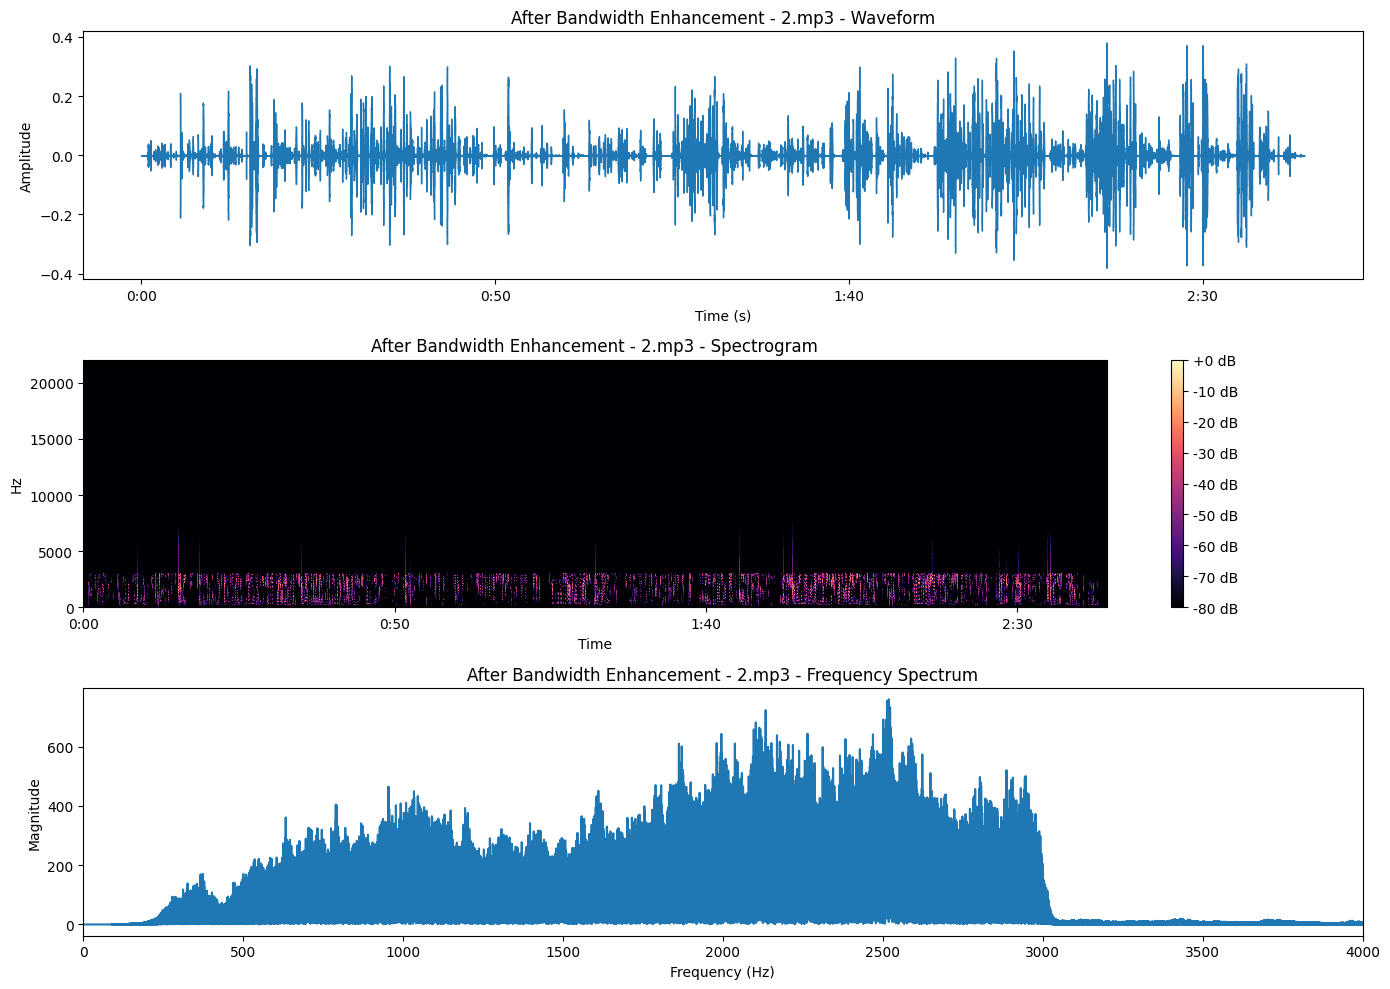

In [ ]:
def enhance_telephone_audio(y, sr):
    # Telephone bandwidth is typically 300-3400 Hz
    # Apply bandpass filter

    # High-pass filter to remove bass (below 300 Hz)
    sos_high = butter(4, 300, btype='high', fs=sr, output='sos')
    y_filtered = sosfilt(sos_high, y)

    # Low-pass filter to remove high frequency noise (above 3400 Hz)
    sos_low = butter(4, 3400, btype='low', fs=sr, output='sos')
    y_filtered = sosfilt(sos_low, y_filtered)

    # Apply gentle pre-emphasis to boost mid-high frequencies (speech clarity)
    pre_emphasis = 0.97
    y_emphasized = np.append(y_filtered[0], y_filtered[1:] - pre_emphasis * y_filtered[:-1])

    return y_emphasized

print("Enhancing telephone audio bandwidth...")
for file in audio_files:
    y_enhanced = enhance_telephone_audio(audio_data[file]['current'],
                                         audio_data[file]['sr'])
    audio_data[file]['enhanced'] = y_enhanced
    audio_data[file]['current'] = y_enhanced
    print(f"  {file}: Bandwidth enhancement complete")

# Visualize result
file = audio_files[0]
plot_audio_analysis(audio_data[file]['enhanced'], audio_data[file]['sr'],
                   f"After Bandwidth Enhancement - {file}")

## Step 6 - Remove Waiting Tone (Optional)
Detect and remove waiting tones (usually around 400-450 Hz)


In [ ]:
# can comment the following cell

Removing waiting tones...
  2.mp3: Tone removal complete
  3.mp3: Tone removal complete
  4.mp3: Tone removal complete


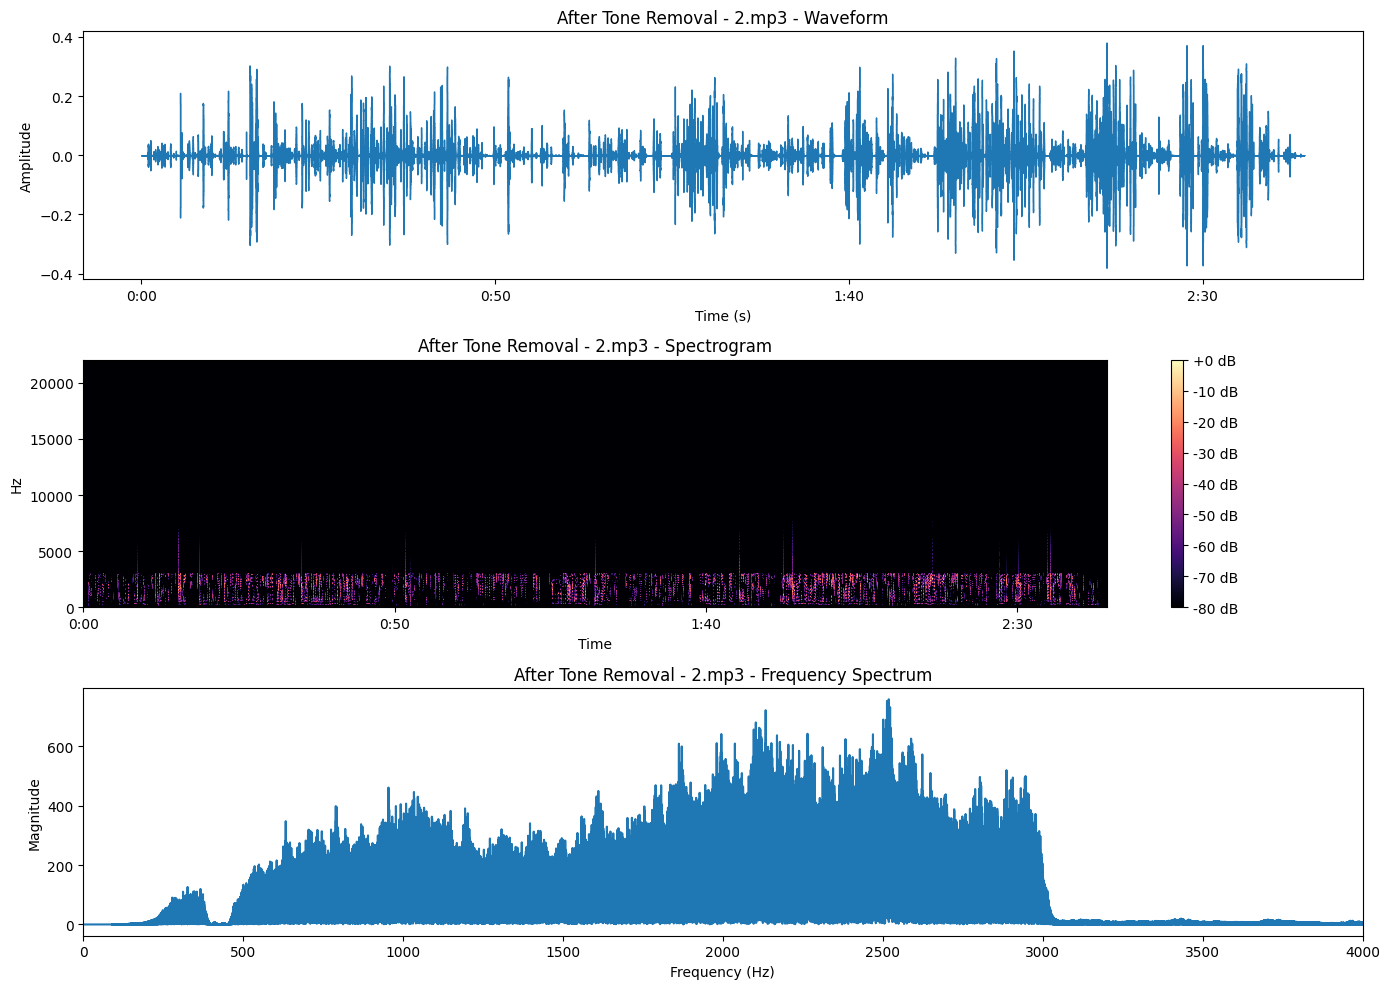

In [ ]:
def remove_tone(y, sr, tone_freq=425, bandwidth=50):
    """Remove specific frequency tone (e.g., waiting tone)"""
    # Design notch filter
    Q = tone_freq / bandwidth
    b, a = signal.iirnotch(tone_freq, Q, sr)

    # Apply filter
    y_notched = signal.filtfilt(b, a, y)

    return y_notched

print("Removing waiting tones...")
for file in audio_files:
    # Remove common waiting tone frequencies
    y_no_tone = remove_tone(audio_data[file]['current'], audio_data[file]['sr'],
                           tone_freq=425, bandwidth=50)
    # Also try 400 Hz and 450 Hz
    y_no_tone = remove_tone(y_no_tone, audio_data[file]['sr'],
                           tone_freq=400, bandwidth=30)
    y_no_tone = remove_tone(y_no_tone, audio_data[file]['sr'],
                           tone_freq=450, bandwidth=30)

    audio_data[file]['no_tone'] = y_no_tone
    audio_data[file]['current'] = y_no_tone
    print(f"  {file}: Tone removal complete")

# Visualize result
file = audio_files[0]
plot_audio_analysis(audio_data[file]['no_tone'], audio_data[file]['sr'],
                   f"After Tone Removal - {file}")


## Final Processing - Wiener Filtering
Apply Wiener filter for final cleanup


In [ ]:
def apply_wiener_filter(y):
    """Apply Wiener filter for noise reduction"""
    # Wiener filtering in frequency domain
    y_filtered = wiener(y, mysize=5)
    return y_filtered

print("Applying final Wiener filtering...")
for file in audio_files:
    y_final = apply_wiener_filter(audio_data[file]['current'])
    # Final normalization
    y_final = normalize_audio(y_final, target_level=-20.0)
    audio_data[file]['final'] = y_final
    audio_data[file]['current'] = y_final
    print(f"  {file}: Final processing complete")

Applying final Wiener filtering...
  2.mp3: Final processing complete
  3.mp3: Final processing complete
  4.mp3: Final processing complete


## Compare Before and After
Compare original and processed audio



Comparison for 2.mp3


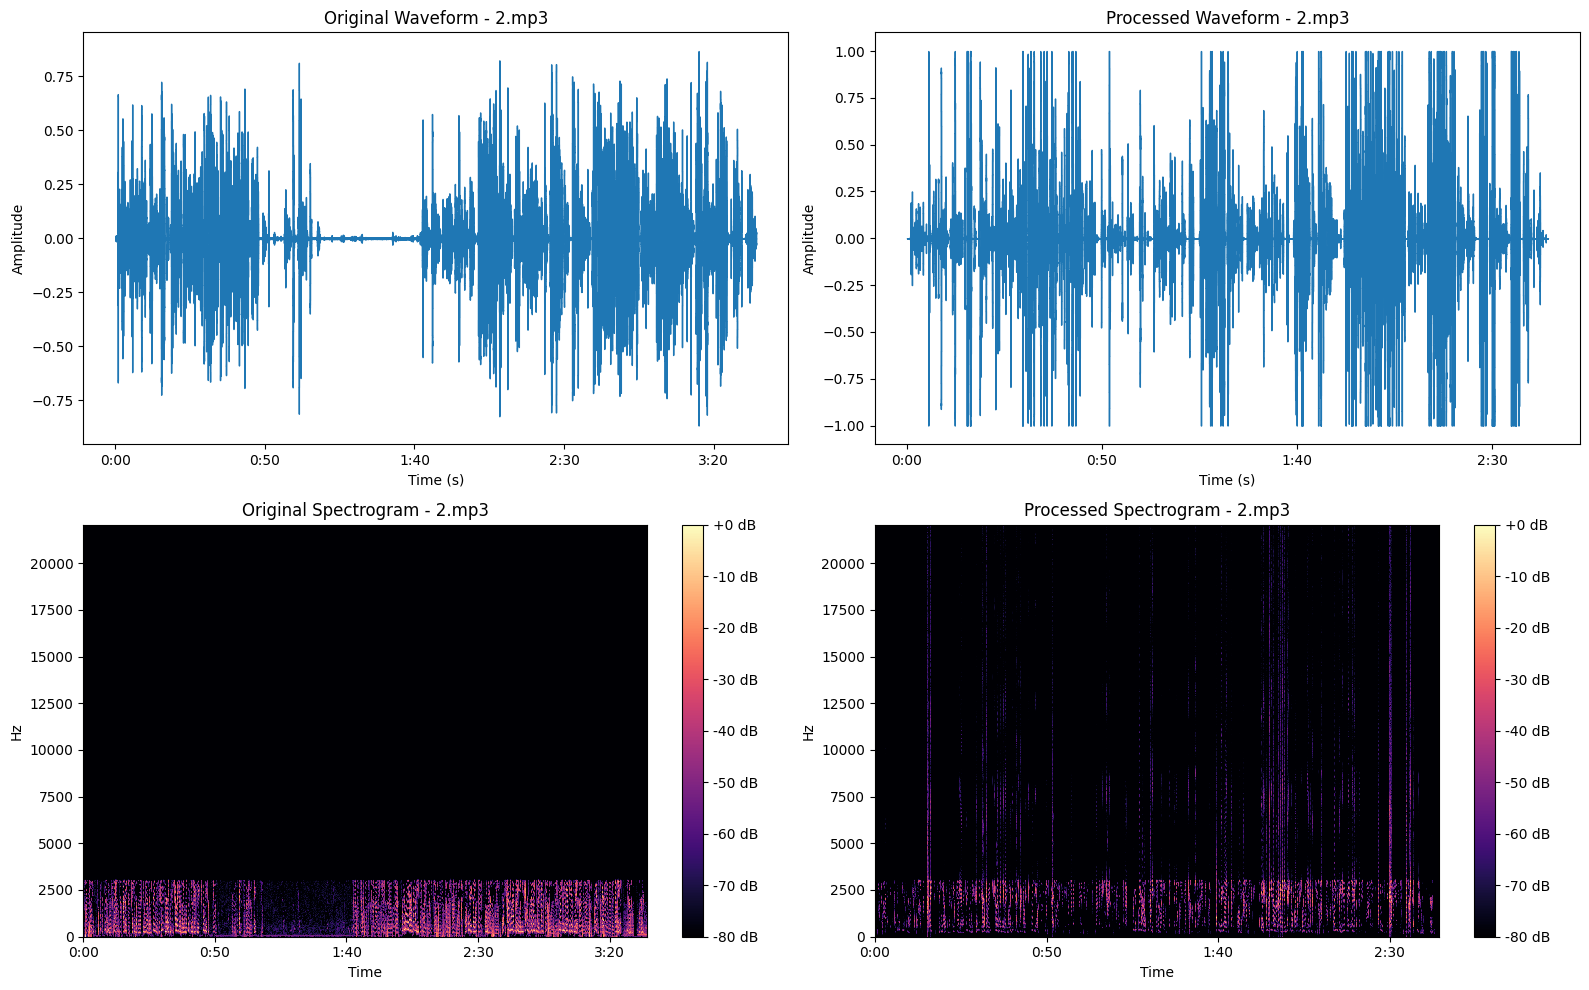


Comparison for 3.mp3


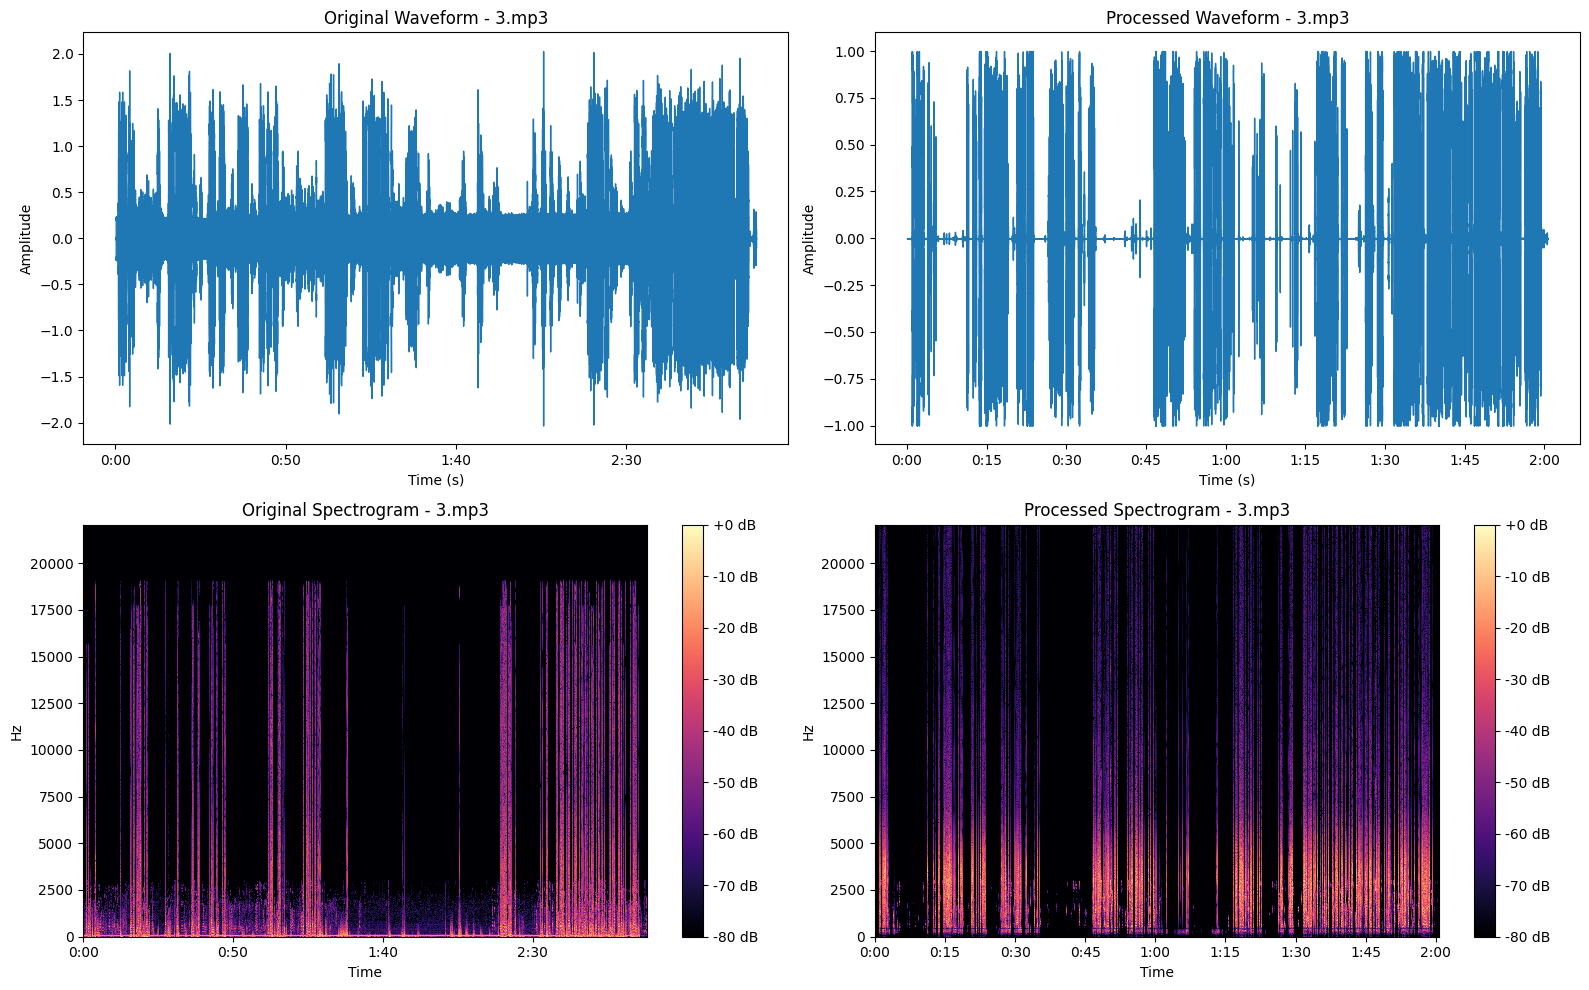


Comparison for 4.mp3


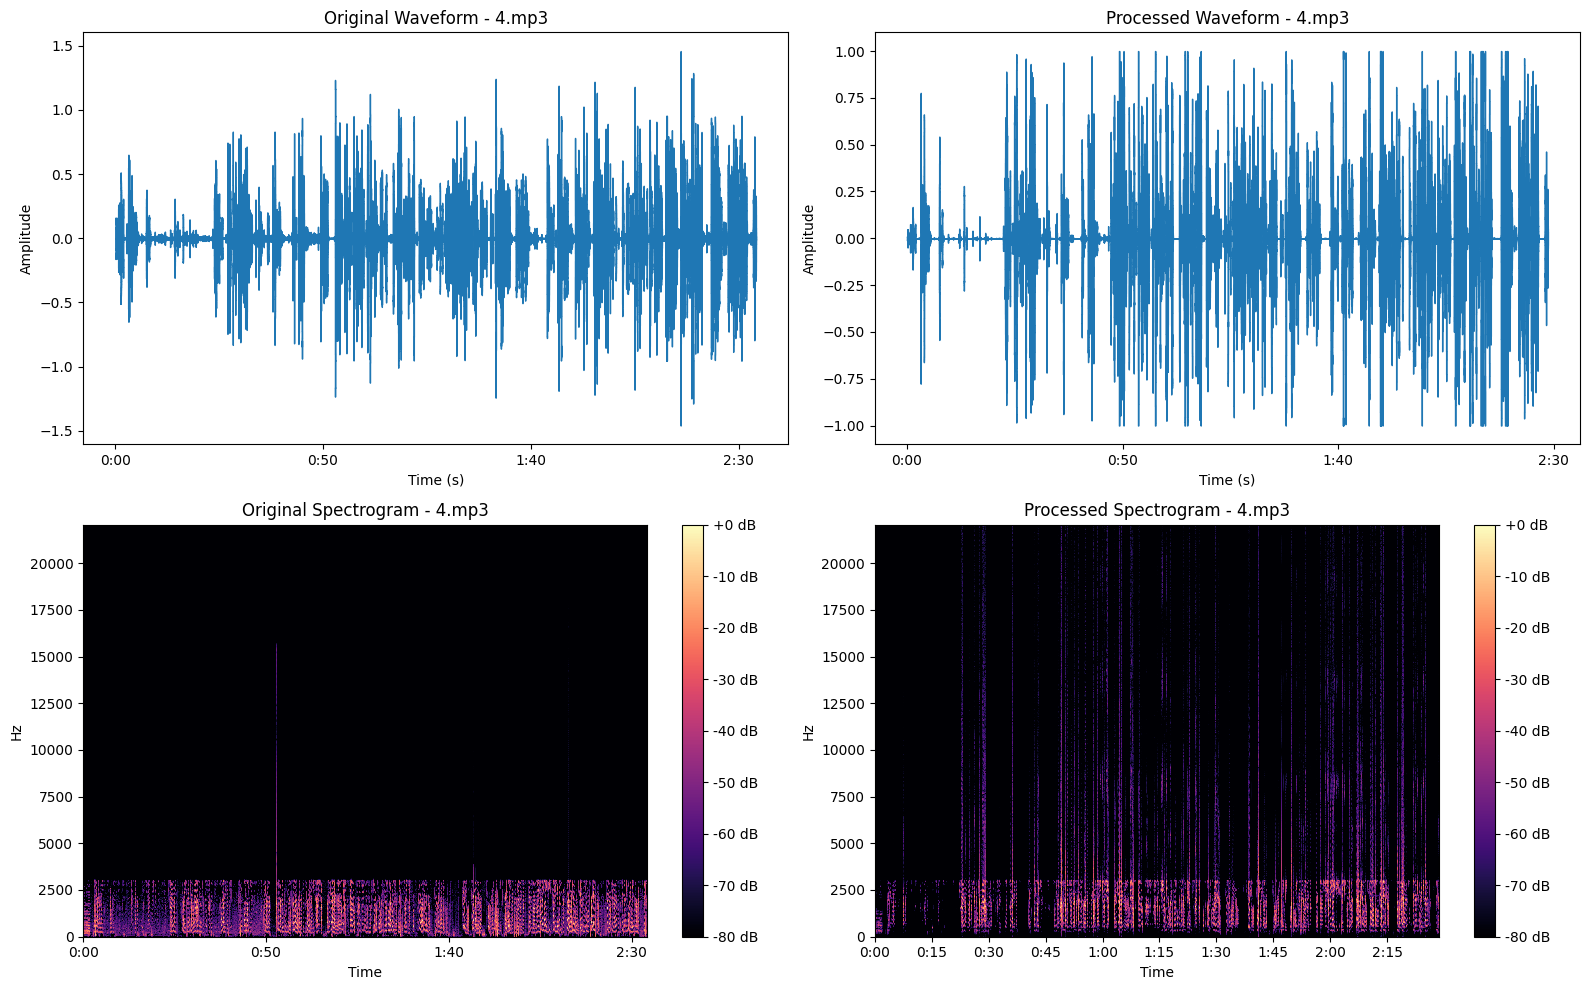

In [ ]:
for file in audio_files:
    print(f"\n{'='*60}")
    print(f"Comparison for {file}")
    print(f"{'='*60}")

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Original waveform
    librosa.display.waveshow(audio_data[file]['original'],
                            sr=audio_data[file]['sr'], ax=axes[0, 0])
    axes[0, 0].set_title(f'Original Waveform - {file}')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Amplitude')

    # Processed waveform
    librosa.display.waveshow(audio_data[file]['final'],
                            sr=audio_data[file]['sr'], ax=axes[0, 1])
    axes[0, 1].set_title(f'Processed Waveform - {file}')
    axes[0, 1].set_xlabel('Time (s)')
    axes[0, 1].set_ylabel('Amplitude')

    # Original spectrogram
    D_orig = librosa.amplitude_to_db(np.abs(librosa.stft(audio_data[file]['original'])),
                                     ref=np.max)
    img1 = librosa.display.specshow(D_orig, sr=audio_data[file]['sr'],
                                    x_axis='time', y_axis='hz', ax=axes[1, 0])
    axes[1, 0].set_title(f'Original Spectrogram - {file}')
    fig.colorbar(img1, ax=axes[1, 0], format='%+2.0f dB')

    # Processed spectrogram
    D_final = librosa.amplitude_to_db(np.abs(librosa.stft(audio_data[file]['final'])),
                                      ref=np.max)
    img2 = librosa.display.specshow(D_final, sr=audio_data[file]['sr'],
                                    x_axis='time', y_axis='hz', ax=axes[1, 1])
    axes[1, 1].set_title(f'Processed Spectrogram - {file}')
    fig.colorbar(img2, ax=axes[1, 1], format='%+2.0f dB')

    plt.tight_layout()
    plt.show()

## Save Processed Audio Files
Save the processed audio files


In [ ]:
output_dir = "processed_audio"
import os
os.makedirs(output_dir, exist_ok=True)

for file in audio_files:
    output_filename = os.path.join(output_dir, f"processed_{file.replace('.mp3', '.wav')}")

    # Save as WAV file (lossless)
    sf.write(output_filename, audio_data[file]['final'], audio_data[file]['sr'])

    print(f"Saved: {output_filename}")

print(f"\nAll processed files saved to '{output_dir}' directory")

Saved: processed_audio/processed_2.wav
Saved: processed_audio/processed_3.wav
Saved: processed_audio/processed_4.wav

All processed files saved to 'processed_audio' directory


## Audio Quality Metrics
Calculate and display quality metrics


In [ ]:
def calculate_snr(original, processed):
    """Calculate Signal-to-Noise Ratio improvement"""
    noise_original = original - processed
    signal_power = np.mean(processed ** 2)
    noise_power = np.mean(noise_original ** 2)

    if noise_power > 0:
        snr = 10 * np.log10(signal_power / noise_power)
        return snr
    return float('inf')

print("Audio Quality Metrics:")
print("="*60)

for file in audio_files:
    print(f"\n{file}:")

    original = audio_data[file]['original']
    final = audio_data[file]['final']
    sr = audio_data[file]['sr']

    # Duration comparison
    orig_duration = len(original) / sr
    final_duration = len(final) / sr
    print(f"  Duration: {orig_duration:.2f}s -> {final_duration:.2f}s")

    # RMS level comparison
    rms_orig = np.sqrt(np.mean(original**2))
    rms_final = np.sqrt(np.mean(final**2))
    print(f"  RMS Level: {20*np.log10(rms_orig):.2f} dB -> {20*np.log10(rms_final):.2f} dB")

    # Dynamic range
    dr_orig = 20 * np.log10(np.max(np.abs(original)) / (rms_orig + 1e-10))
    dr_final = 20 * np.log10(np.max(np.abs(final)) / (rms_final + 1e-10))
    print(f"  Dynamic Range: {dr_orig:.2f} dB -> {dr_final:.2f} dB")

print("\n" + "="*60)
print("Processing complete! Check the 'processed_audio' directory for output files.")

Audio Quality Metrics:

2.mp3:
  Duration: 214.23s -> 164.37s
  RMS Level: -23.95 dB -> -20.04 dB
  Dynamic Range: 22.71 dB -> 20.04 dB

3.mp3:
  Duration: 188.16s -> 120.68s
  RMS Level: -9.30 dB -> -20.00 dB
  Dynamic Range: 15.46 dB -> 20.00 dB

4.mp3:
  Duration: 154.25s -> 148.68s
  RMS Level: -20.91 dB -> -20.00 dB
  Dynamic Range: 24.20 dB -> 20.00 dB

Processing complete! Check the 'processed_audio' directory for output files.


In [ ]:
!zip -r claude_results processed_audio

  adding: processed_audio/ (stored 0%)
  adding: processed_audio/processed_3.wav (deflated 43%)
  adding: processed_audio/processed_2.wav (deflated 35%)
  adding: processed_audio/processed_4.wav (deflated 33%)
